In [ ]:
# import libraries for data work, modeling, and plots
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# resolve project root whether jupyter sets cwd to notebooks/ or to the project root
_cwd = Path().resolve()
PROJECT_DIR = _cwd if (_cwd / 'data').exists() else _cwd.parent
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

torch.manual_seed(22)
np.random.seed(22)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

print('project dir:', PROJECT_DIR)
print('device:', device)


In [62]:
# load the processed train, validation, and test splits
train = pd.read_csv(PROCESSED_DIR / 'train.csv', parse_dates=['hour'])
val = pd.read_csv(PROCESSED_DIR / 'val.csv', parse_dates=['hour'])
test = pd.read_csv(PROCESSED_DIR / 'test.csv', parse_dates=['hour'])

target = 'pickups'
categorical_cols = ['cluster_id', 'hour_of_day', 'day_of_week', 'month']
numeric_cols = [
    'cluster_capacity',
    'is_weekend',
    'is_rush_hour',
    'is_holiday',
    'temperature_c',
    'precipitation_mm',
    'wind_speed_kmh',
    'is_rainy',
    'lag_24h',
]

print(train.shape, val.shape, test.shape)
print('categorical cols:', categorical_cols)
print('numeric cols:', numeric_cols)


(69888, 15) (5952, 15) (5376, 15)
categorical cols: ['cluster_id', 'hour_of_day', 'day_of_week', 'month']
numeric cols: ['cluster_capacity', 'is_weekend', 'is_rush_hour', 'is_holiday', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_rainy', 'lag_24h']


In [63]:
# scale numeric features using only the training split
scaler = StandardScaler()
train_num = scaler.fit_transform(train[numeric_cols]).astype(np.float32)
val_num = scaler.transform(val[numeric_cols]).astype(np.float32)
test_num = scaler.transform(test[numeric_cols]).astype(np.float32)

# one-hot encode categorical features so all splits share the same columns
all_cat = pd.get_dummies(
    pd.concat([train[categorical_cols], val[categorical_cols], test[categorical_cols]], ignore_index=True).astype(str),
    columns=categorical_cols,
    dtype=float,
)

n_train = len(train)
n_val = len(val)

train_cat = all_cat.iloc[:n_train].to_numpy(dtype=np.float32)
val_cat = all_cat.iloc[n_train:n_train + n_val].to_numpy(dtype=np.float32)
test_cat = all_cat.iloc[n_train + n_val:].to_numpy(dtype=np.float32)

# combine numeric and categorical features into final model matrices
X_train = np.hstack([train_num, train_cat])
X_val = np.hstack([val_num, val_cat])
X_test = np.hstack([test_num, test_cat])

y_train = train[target].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val[target].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test[target].to_numpy(dtype=np.float32).reshape(-1, 1)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))

print('input dimension:', X_train.shape[1])
print('train tensor shape:', tuple(X_train_tensor.shape))


input dimension: 60
train tensor shape: (69888, 60)


In [68]:
# define an MLP for tabular regression
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        layers.append(nn.Softplus())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# try a few simple MLP configurations for a fixed number of epochs
input_dim = X_train.shape[1]
batch_size = 512
num_epochs = 15

mlp_configs = [
    {'hidden_dims': [128, 64], 'dropout': 0.10, 'lr': 1e-3, 'weight_decay': 1e-4},
    {'hidden_dims': [256, 128], 'dropout': 0.20, 'lr': 1e-3, 'weight_decay': 1e-4},
    {'hidden_dims': [128, 64, 32], 'dropout': 0.20, 'lr': 5e-4, 'weight_decay': 1e-4},
]

loss_fn = nn.MSELoss()
history_rows = []
best_params = None
best_state = None
best_epoch = None
best_val_rmse = float('inf')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for config in mlp_configs:
    model = MLP(input_dim, config['hidden_dims'], config['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

    best_config_val_rmse = float('inf')
    best_config_state = None
    best_config_epoch = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            pred = model(batch_X)
            loss = loss_fn(pred, batch_y)
            loss.backward()
            optimizer.step()

        # score both splits in eval mode so the losses are comparable
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_tensor)
            val_pred = model(X_val_tensor)

        train_loss = loss_fn(train_pred, y_train_tensor).item()
        val_loss = loss_fn(val_pred, y_val_tensor).item()
        train_rmse = np.sqrt(mean_squared_error(y_train.reshape(-1), train_pred.cpu().numpy().reshape(-1)))
        val_rmse = np.sqrt(mean_squared_error(y_val.reshape(-1), val_pred.cpu().numpy().reshape(-1)))

        history_rows.append({
            'hidden_dims': str(config['hidden_dims']),
            'dropout': config['dropout'],
            'lr': config['lr'],
            'weight_decay': config['weight_decay'],
            'batch_size': batch_size,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_RMSE': train_rmse,
            'val_RMSE': val_rmse,
        })

        if val_rmse < best_config_val_rmse:
            best_config_val_rmse = val_rmse
            best_config_state = copy.deepcopy(model.state_dict())
            best_config_epoch = epoch

    if best_config_val_rmse < best_val_rmse:
        best_val_rmse = best_config_val_rmse
        best_params = {**config, 'batch_size': batch_size}
        best_state = best_config_state
        best_epoch = best_config_epoch

history_df = pd.DataFrame(history_rows)
print('best params:', best_params)
print('best epoch:', best_epoch)
print('best validation RMSE:', round(best_val_rmse, 4))


best params: {'hidden_dims': [128, 64, 32], 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 512}
best epoch: 8
best validation RMSE: 32.8925


In [69]:
# rebuild the best model, load the best weights, and evaluate all splits
best_model = MLP(X_train.shape[1], best_params['hidden_dims'], best_params['dropout']).to(device)
best_model.load_state_dict(best_state)
best_model.eval()

with torch.no_grad():
    train_pred = best_model(X_train_tensor).cpu().numpy().reshape(-1)
    val_pred = best_model(X_val_tensor).cpu().numpy().reshape(-1)
    test_pred = best_model(X_test_tensor).cpu().numpy().reshape(-1)

metrics_df = pd.DataFrame([
    {
        'model': 'PyTorch MLP',
        'split': 'train',
        'MAE': mean_absolute_error(y_train.reshape(-1), train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train.reshape(-1), train_pred)),
        'R2': r2_score(y_train.reshape(-1), train_pred),
    },
    {
        'model': 'PyTorch MLP',
        'split': 'val',
        'MAE': mean_absolute_error(y_val.reshape(-1), val_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val.reshape(-1), val_pred)),
        'R2': r2_score(y_val.reshape(-1), val_pred),
    },
    {
        'model': 'PyTorch MLP',
        'split': 'test',
        'MAE': mean_absolute_error(y_test.reshape(-1), test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test.reshape(-1), test_pred)),
        'R2': r2_score(y_test.reshape(-1), test_pred),
    },
])

print(metrics_df.round(4))


         model  split      MAE     RMSE      R2
0  PyTorch MLP  train  24.5200  78.2778  0.9234
1  PyTorch MLP    val  10.0662  32.8925  0.8197
2  PyTorch MLP   test   7.6069  23.5206  0.8519


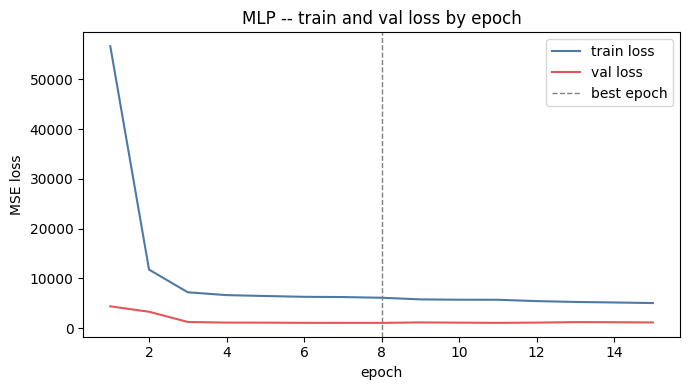

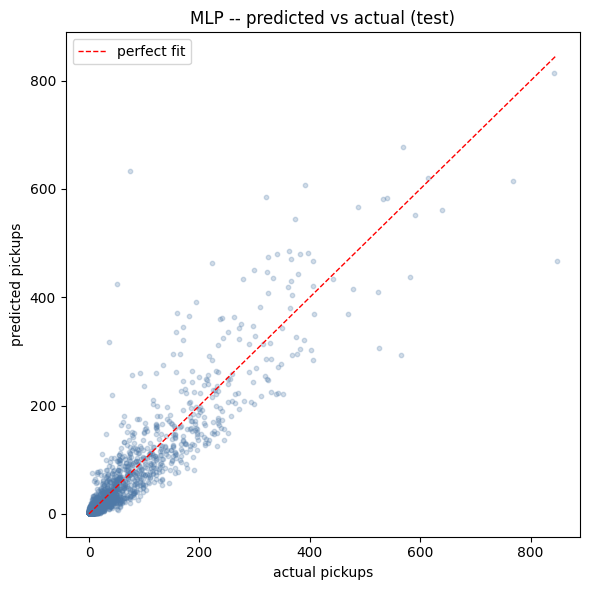

saved results to the results/ folder


In [71]:
# save metrics, best parameters, training history, and plots
metrics_df.to_csv(RESULTS_DIR / 'pytorch_mlp_metrics.csv', index=False)
history_df.to_csv(RESULTS_DIR / 'pytorch_mlp_training_history.csv', index=False)

best_params_payload = {
    **best_params,
    'best_epoch': best_epoch,
    'best_val_rmse': best_val_rmse,
}

with open(RESULTS_DIR / 'pytorch_mlp_best_params.json', 'w') as f:
    json.dump(best_params_payload, f, indent=2)

best_history = history_df[
    (history_df['hidden_dims'] == str(best_params['hidden_dims']))
    & (history_df['dropout'] == best_params['dropout'])
    & (history_df['lr'] == best_params['lr'])
    & (history_df['weight_decay'] == best_params['weight_decay'])
    & (history_df['batch_size'] == best_params['batch_size'])
].copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_history['epoch'], best_history['train_loss'], label='train loss', color='#4e79a7')
ax.plot(best_history['epoch'], best_history['val_loss'], label='val loss', color='#e15759')
ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label='best epoch')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE loss')
ax.set_title('MLP -- train and val loss by epoch')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pytorch_mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.reshape(-1), test_pred, alpha=0.25, s=10, color='#4e79a7')
max_val = max(float(np.max(y_test)), float(np.max(test_pred)))
ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label='perfect fit')
ax.set_xlabel('actual pickups')
ax.set_ylabel('predicted pickups')
ax.set_title('MLP -- predicted vs actual (test)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pytorch_mlp_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print('saved results to the results/ folder')
